# Avance de Proyecto: Estimacion del riesgo de diabetes en pacientes mexicanos
### Algoritmos de Aprendizaje Automatico

Dataset: `Diabetes_Mexico.csv` (adaptacion de encuesta nacional de salud, tipo ENSANUT)


## 2. Seleccion del conjunto de datos

| Elemento | Informacion |
|---|---|
| Nombre del dataset | Diabetes_Mexico.csv |
| Fuente | Encuesta de salud de tipo poblacional en Mexico (estructura compatible con ENSANUT), proporcionada para fines academicos del curso |
| Liga de acceso | Archivo proporcionado por la institucion educativa (uso academico) |
| Fecha de consulta | 01 de septiembre de 2026 |
| Numero de observaciones | 2,549 registros |
| Numero de variables | 24 variables originales |
| Formato original del archivo | CSV (valores separados por comas, con notacion decimal en coma en algunas columnas) |
| Variable objetivo | `riesgo_diabetes_cat` (0 = sin riesgo, 1 = diagnosticado previamente, 2 = en riesgo) |

El dataset cumple con las condiciones necesarias: incluye una variable objetivo categorica
relacionada con el riesgo de diabetes, contiene variables numericas y categoricas, tiene
suficientes registros para particionar en entrenamiento/validacion/prueba, permite procesos
de limpieza, codificacion y escalamiento, y cuenta con variables clinicamente relacionadas con
la permanencia/evolucion del riesgo de un paciente.


## 4. Pregunta de analisis

> **¿Como pueden utilizarse los datos demograficos, antropometricos y bioquimicos
> complementarios de los pacientes para estimar su riesgo de diabetes bajo las
> condiciones clinicas mas relevantes consideradas, sin depender directamente del
> resultado del examen de glucosa, de manera que se apoyen acciones de priorizacion y
> prevencion mediante un modelo reproducible de aprendizaje automatico?**

La pregunta conserva el enfoque en clasificacion (ahora multiclase), en riesgo de una
condicion de salud (equivalente al abandono del planteamiento original), en apoyo a la toma de
decisiones (priorizacion en vez de decisiones automaticas) y en reproducibilidad
(semilla fija, pipeline documentado, particiones registradas).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve,
                              ConfusionMatrixDisplay, classification_report)

import sklearn, sys
print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

RANDOM_STATE = 42
plt.rcParams.update({'font.size': 11})
sns.set_style('whitegrid')

Python: 3.13.15
Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 1.6.1


## 5. Diccionario de variables

| Variable | Descripcion | Tipo original | Tipo analitico | Rol | Unidad / escala | Valores faltantes | Tratamiento previsto |
|---|---|---|---|---|---|---|---|
| folio_i | Identificador del hogar/vivienda | texto | identificador | Excluir | - | 0% | Eliminar (identificador) |
| folio_int | Identificador del individuo dentro del hogar | texto | identificador | Excluir | - | 0% | Eliminar (identificador) |
| sexo | Sexo del paciente | texto | categorica binaria | Predictora | Mujer/Hombre | 0% | One-Hot Encoding |
| edad | Edad del paciente | numerico | numerica continua | Predictora | anios | 0.98% | Imputacion por mediana + escalamiento |
| Ciudad | Municipio de residencia | texto | categorica (267 categorias) | Excluir | - | 0% | Eliminar por exceso de categorias; se sustituye por `entidad_cve` |
| entidad_cve (derivada) | Entidad federativa, extraida de los primeros 2 digitos del folio | texto | categorica (31 categorias) | Predictora | codigo INEGI | 0% | One-Hot Encoding |
| Peso | Peso corporal | texto (coma decimal) | numerica continua | Auxiliar | kg | 28.2% | Conversion a numerico; usada solo para calcular IMC |
| Estatura | Estatura | texto (coma decimal) | numerica continua | Auxiliar | cm | 28.2% | Conversion a numerico; usada solo para calcular IMC |
| imc | Indice de masa corporal (original) | numerico | numerica continua | Excluir | kg/m2 | 98.6% | Eliminar: casi enteramente vacia, se sustituye por `imc_calc` |
| imc_calc (derivada) | IMC recalculado = Peso/(Estatura/100)^2 | numerico | numerica continua | Predictora | kg/m2 | 28.2% | Imputacion por mediana + escalamiento |
| muestra_suero | Indicador de muestra de suero tomada | numerico | categorica | Excluir | - | 0% | Eliminar: variable con una sola categoria (constante = 1) |
| ac_urico | Acido urico | texto (coma decimal) | numerica continua | Predictora | mg/dL | 0% | Conversion a numerico, imputacion + escalamiento |
| albu | Albumina | texto (coma decimal) | numerica continua | Predictora | g/dL | 0% | Conversion a numerico, imputacion + escalamiento |
| col_hdl | Colesterol HDL | texto | numerica continua | Predictora | mg/dL | 0% | Conversion a numerico, imputacion + escalamiento |
| col_ldl | Colesterol LDL | numerico | numerica continua | Predictora | mg/dL | 0% | Imputacion + escalamiento |
| colest | Colesterol total | numerico | numerica continua | Predictora | mg/dL | 0% | Imputacion + escalamiento |
| creat | Creatinina | texto (coma decimal) | numerica continua | Predictora | mg/dL | 0% | Conversion a numerico, imputacion + escalamiento |
| glu_suero | Glucosa en suero (ayuno) | numerico | numerica continua | **Excluir (fuga)** | mg/dL | ~0% | Eliminar: determina directamente la variable objetivo |
| insulina | Insulina | texto (coma decimal) | numerica continua | Predictora | µU/mL | 0% | Conversion a numerico, imputacion + escalamiento |
| trig | Trigliceridos | numerico | numerica continua | Predictora | mg/dL | 0% | Imputacion + escalamiento |
| hb1ac | Hemoglobina glucosilada | numerico | numerica continua | **Excluir (fuga + faltantes)** | % | 90.5% | Eliminar: marcador diagnostico directo y casi enteramente vacio |
| ponde_venosa | Factor de ponderacion muestral (sangre venosa) | texto (coma decimal) | numerica (diseno muestral) | Excluir | - | 3.9% | Eliminar: factor de diseno de encuesta, no es un atributo clinico del paciente |
| estrato | Estrato de diseno muestral | numerico | categorica (diseno muestral) | Excluir | 1-3 | 0% | Eliminar: variable de diseno de encuesta |
| est_sel | Estrato de seleccion | numerico | categorica (diseno muestral) | Excluir | - | 0% | Eliminar: variable de diseno de encuesta |
| ponde_hemo | Factor de ponderacion muestral (hemoglobina) | texto (coma decimal) | numerica (diseno muestral) | Excluir | - | 38.4% | Eliminar: factor de diseno de encuesta |
| riesgo_diabetes_cat | Categoria de riesgo de diabetes | numerico | categorica (0,1,2) | **Objetivo** | 0/1/2 | 0% | Variable a predecir |

**Variables excluidas como predictoras y justificacion:**
- `folio_i`, `folio_int`: identificadores unicos, sin valor predictivo.
- `Ciudad`: 267 categorias distintas, impractico para codificacion y con alto riesgo de sobreajuste; se sustituye por la entidad federativa (`entidad_cve`, 31 categorias), extraida de los primeros dos digitos del folio del INEGI.
- `imc`: 98.6% de valores faltantes; se sustituye por `imc_calc`, calculado a partir de `Peso` y `Estatura`, con solo 28.2% de faltantes.
- `muestra_suero`: constante (una sola categoria), no aporta informacion.
- `estrato`, `est_sel`, `ponde_venosa`, `ponde_hemo`: son variables del **diseno muestral** de la encuesta (pesos de expansion y estratos), no describen condiciones clinicas del paciente y no deben usarse como predictores clinicos.
- `glu_suero`, `hb1ac`: se identifican como **fuga de informacion** directa (ver seccion 10) y se excluyen del conjunto de predictoras.


## 6. Carga y exploracion inicial

In [ ]:
df = pd.read_csv('/content/Diabetes_Mexico.csv')
print("Dimensiones (filas, columnas):", df.shape)
df.head()

Dimensiones (filas, columnas): (2549, 24)


,folio_i,folio_int,sexo,edad,Ciudad,Peso,Estatura,imc,muestra_suero,ac_urico,...,creat,glu_suero,insulina,trig,hb1ac,ponde_venosa,estrato,est_sel,ponde_hemo,riesgo_diabetes_cat
0,2024_01001010,2024_01001010_01,Mujer,89.0,AGUASCALIENTES,NaN,NaN,NaN,1.0,"4,1",...,"0,62",166.0,"4,7",107.0,NaN,"2245,917738",3.0,13.0,"2888,530238",2
1,2024_01001012,2024_01001012_01,Mujer,71.0,AGUASCALIENTES,NaN,NaN,32.0,1.0,"4,3",...,"0,64",98.0,"9,6",132.0,NaN,"2245,917738",3.0,13.0,"2888,530238",1
2,2024_01001016,2024_01001016_02,Mujer,57.0,AGUASCALIENTES,"80,25","170,6",NaN,1.0,"4,9",...,"0,6",128.0,"4,7",263.0,6.0,"4047,445276",3.0,13.0,NaN,2
3,2024_01001016,2024_01001016_05,Mujer,20.0,AGUASCALIENTES,"68,6","166,2",NaN,1.0,"4,9",...,"0,63",112.0,"10,1",238.0,NaN,"13079,14232",3.0,13.0,"13776,80526",2
4,2024_01001031,2024_01001031_01,Hombre,74.0,AGUASCALIENTES,NaN,NaN,NaN,1.0,"6,4",...,"1,09",97.0,"10,2",135.0,NaN,"5292,158204",3.0,13.0,"5824,779445",0


In [ ]:
df.tail()

,folio_i,folio_int,sexo,edad,Ciudad,Peso,Estatura,imc,muestra_suero,ac_urico,...,creat,glu_suero,insulina,trig,hb1ac,ponde_venosa,estrato,est_sel,ponde_hemo,riesgo_diabetes_cat
2544,2024_32056012,2024_32056012_01,Mujer,66.0,ZACATECAS,NaN,NaN,NaN,1.0,"4,8",...,"0,72",89.0,"6,4",179.0,NaN,"6532,590705",3.0,323.0,"9897,955004",0
2545,2024_32056022,2024_32056022_02,Mujer,51.0,ZACATECAS,"97,6","171,2",NaN,1.0,"5,8",...,"0,69",98.0,"35,2",126.0,NaN,"13055,89557",3.0,323.0,NaN,0
2546,2024_32056024,2024_32056024_01,Hombre,45.0,ZACATECAS,"90,95","172,4",NaN,1.0,"6,7",...,"0,82",94.0,"17,8",119.0,NaN,"6394,811934",3.0,323.0,NaN,0
2547,2024_32056024,2024_32056024_02,Mujer,38.0,ZACATECAS,"69,3","152,8",NaN,1.0,"4,6",...,"0,56",88.0,"10,7",132.0,5.0,"13189,49573",3.0,323.0,"20012,01206",0
2548,2024_32056029,2024_32056029_01,Hombre,44.0,ZACATECAS,"76,85","164,4",NaN,1.0,"6,5",...,"0,67",136.0,"3,7",73.0,NaN,"63723,9608",3.0,323.0,NaN,2


In [ ]:
print("Nombres de columnas:")
print(list(df.columns))
print()
print("Tipos de datos detectados al cargar:")
print(df.dtypes)

Nombres de columnas:
['folio_i', 'folio_int', 'sexo', 'edad', 'Ciudad', 'Peso', 'Estatura', 'imc', 'muestra_suero', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'creat', 'glu_suero', 'insulina', 'trig', 'hb1ac', 'ponde_venosa', 'estrato', 'est_sel', 'ponde_hemo', 'riesgo_diabetes_cat']

Tipos de datos detectados al cargar:
folio_i                 object
folio_int               object
sexo                    object
edad                   float64
Ciudad                  object
Peso                    object
Estatura                object
imc                    float64
muestra_suero          float64
ac_urico                object
albu                    object
col_hdl                 object
col_ldl                float64
colest                 float64
creat                   object
glu_suero              float64
insulina                object
trig                   float64
hb1ac                  float64
ponde_venosa            object
estrato                float64
est_sel          

In [ ]:
print("Numero de valores unicos por variable:")
print(df.nunique())

Numero de valores unicos por variable:
folio_i                2055
folio_int              2549
sexo                      2
edad                     77
Ciudad                  267
Peso                    961
Estatura                413
imc                      17
muestra_suero             1
ac_urico                 89
albu                     44
col_hdl                  72
col_ldl                 171
colest                  228
creat                   148
glu_suero               241
insulina                400
trig                    381
hb1ac                     8
ponde_venosa           2294
estrato                   3
est_sel                  91
ponde_hemo             1480
riesgo_diabetes_cat       3
dtype: int64


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
folio_i,2549,2055,2024_07051013,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
folio_int,2549,2549,2024_32056029_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexo,2549,2,Mujer,1547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,2524.0,NaN,NaN,NaN,35.763074,319.672846,-7975.0,34.0,47.5,62.0,95.0
Ciudad,2549,267,AGUASCALIENTES,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Peso,1829,961,"222,22",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estatura,1829,413,157,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imc,35.0,NaN,NaN,NaN,29.971429,7.633077,15.0,25.0,30.0,32.5,56.0
muestra_suero,2549.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ac_urico,2549,89,"4,8",95,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Valores faltantes por columna:")
print(df.isna().sum())
print()
print("Registros duplicados (fila completa):", df.duplicated().sum())
print("folio_i duplicados (varias muestras por hogar):", df['folio_i'].duplicated().sum())

Valores faltantes por columna:
folio_i                   0
folio_int                 0
sexo                      0
edad                     25
Ciudad                    0
Peso                    720
Estatura                720
imc                    2514
muestra_suero             0
ac_urico                  0
albu                      0
col_hdl                   0
col_ldl                   0
colest                    0
creat                     0
glu_suero                 0
insulina                  0
trig                      0
hb1ac                  2308
ponde_venosa             99
estrato                   0
est_sel                   0
ponde_hemo              980
riesgo_diabetes_cat       0
dtype: int64

Registros duplicados (fila completa): 0
folio_i duplicados (varias muestras por hogar): 494


In [ ]:
print("Distribucion de la variable objetivo:")
print(df['riesgo_diabetes_cat'].value_counts())
print(df['riesgo_diabetes_cat'].value_counts(normalize=True).round(4)*100)

Distribucion de la variable objetivo:
riesgo_diabetes_cat
0    1697
2     840
1      12
Name: count, dtype: int64
riesgo_diabetes_cat
0    66.58
2    32.95
1     0.47
Name: proportion, dtype: float64


**Interpretacion del estado inicial.** El dataset contiene 2,549 registros y 24 variables,
sin registros completamente duplicados, aunque existen 494 folios de hogar repetidos porque un
mismo hogar puede aportar mas de un integrante encuestado (no representa un error de captura).
Las variables `Peso`, `Estatura`, `imc`, `hb1ac` y `ponde_hemo` presentan cantidades relevantes
de valores faltantes. Varias columnas numericas (`Peso`, `Estatura`, `ac_urico`, `albu`,
`creat`, `insulina`, `ponde_venosa`, `ponde_hemo`) se cargaron como texto debido al uso de coma
como separador decimal. La variable objetivo esta desbalanceada: 66.6% sin riesgo, 32.9% en
riesgo y solo 0.5% clasificado como diagnosticado previamente.


## 7. Analisis de la calidad de los datos

In [ ]:
# Conversion de columnas numericas almacenadas como texto (coma decimal)
coma_cols = ['Peso','Estatura','ac_urico','albu','col_hdl','creat','insulina','ponde_venosa','ponde_hemo']
for c in coma_cols:
    df[c] = df[c].astype(str).str.replace(',', '.', regex=False)
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Variable IMC recalculada (la original tiene 98.6% de valores faltantes)
df['imc_calc'] = df['Peso'] / (df['Estatura']/100)**2

# Entidad federativa extraida del folio (substituye a Ciudad, con demasiadas categorias)
df['entidad_cve'] = df['folio_i'].astype(str).str.split('_').str[1].str[:2]

print("Conversion completada.")
print(df[coma_cols + ['imc_calc','entidad_cve']].dtypes)

Conversion completada.
Peso            float64
Estatura        float64
ac_urico        float64
albu            float64
col_hdl         float64
creat           float64
insulina        float64
ponde_venosa    float64
ponde_hemo      float64
imc_calc        float64
entidad_cve      object
dtype: object


**Tabla de diagnostico de calidad de datos**

| Problema detectado | Variable(s) afectada(s) | Evidencia | Posible impacto | Tratamiento propuesto |
|---|---|---|---|---|
| Columnas numericas almacenadas como texto (coma decimal) | Peso, Estatura, ac_urico, albu, col_hdl, creat, insulina, ponde_venosa, ponde_hemo | `dtype=object`, valores como "4,1" | No podrian usarse en modelos numericos sin conversion | Reemplazar coma por punto y convertir con `pd.to_numeric` |
| Valores faltantes moderados | Peso, Estatura (28.2%), edad (0.98%) | Conteo de `isna()` | Reduce observaciones utiles si no se imputa | Imputacion por mediana dentro de un pipeline ajustado solo con entrenamiento |
| Valores faltantes extremos | imc (98.6%), hb1ac (90.5%), ponde_hemo (38.4%) | Conteo de `isna()` | Variable practicamente inutilizable / imputacion poco confiable | Eliminar `imc` (se recalcula); eliminar `hb1ac` (ademas es fuga); eliminar `ponde_hemo` (variable de diseno) |
| Variable con una sola categoria | muestra_suero | `nunique()==1` | No aporta poder predictivo | Eliminar del conjunto de predictoras |
| Variable con demasiadas categorias | Ciudad (267 categorias) | `nunique()==267` | Alto riesgo de sobreajuste con One-Hot Encoding | Sustituir por `entidad_cve` (31 categorias), derivada del folio |
| Posibles fugas de informacion | glu_suero, hb1ac | Ver seccion 10 | Inflarian artificialmente las metricas | Eliminar del conjunto de predictoras |
| Variables de diseno muestral, no clinicas | estrato, est_sel, ponde_venosa, ponde_hemo | Descripcion metodologica del dataset | No describen condiciones de salud del paciente | Eliminar del conjunto de predictoras |
| Registros repetidos por hogar (no exactamente duplicados) | folio_i | 494 folios repetidos, 0 filas identicas | Ninguno (cada fila es un individuo distinto) | Conservar; no se trata de un error |
| Desbalance de la variable objetivo | riesgo_diabetes_cat | 66.6% / 32.9% / 0.5% | Riesgo de que el modelo ignore la clase minoritaria | Ver seccion 9; uso de `class_weight='balanced'` y metricas macro |
| Posible valor atipico extremo | glu_suero | Valor maximo de 1116 mg/dL | Puede distorsionar estadisticos descriptivos | Se documenta como valor real de un caso extremo; no se elimina sin evidencia clinica de error de captura, y de cualquier forma se excluye como predictora |

No se eliminan registros del dataset: los problemas identificados se resuelven mediante
conversion de tipos, imputacion dentro del pipeline y seleccion justificada de columnas.


## 8. Analisis exploratorio de datos (EDA)

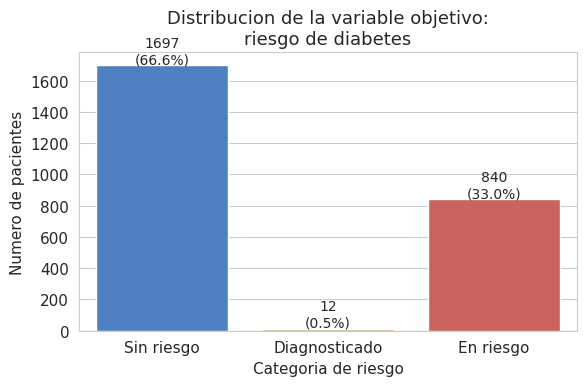

In [ ]:
etiquetas = {0: 'Sin riesgo', 1: 'Diagnosticado', 2: 'En riesgo'}
df['riesgo_label'] = df['riesgo_diabetes_cat'].map(etiquetas)
pal = {'Sin riesgo': '#3B7DD8', 'Diagnosticado': '#E8A33D', 'En riesgo': '#D9534F'}
order = [0,1,2]

plt.figure(figsize=(6,4))
counts = df['riesgo_diabetes_cat'].value_counts().reindex(order)
ax = sns.barplot(x=[etiquetas[i] for i in order], y=counts.values,
                  hue=[etiquetas[i] for i in order], palette=pal, legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v+15, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10)
plt.title('Distribucion de la variable objetivo:\nriesgo de diabetes', fontsize=13)
plt.ylabel('Numero de pacientes')
plt.xlabel('Categoria de riesgo')
plt.tight_layout()
plt.show()

**Interpretacion.** La categoria "sin riesgo" domina el conjunto de datos (66.6%), seguida
de "en riesgo" (32.9%); la categoria "diagnosticado" es extremadamente minoritaria (0.5%, solo
12 casos), lo que anticipa dificultades serias para que cualquier modelo la identifique de
forma confiable.


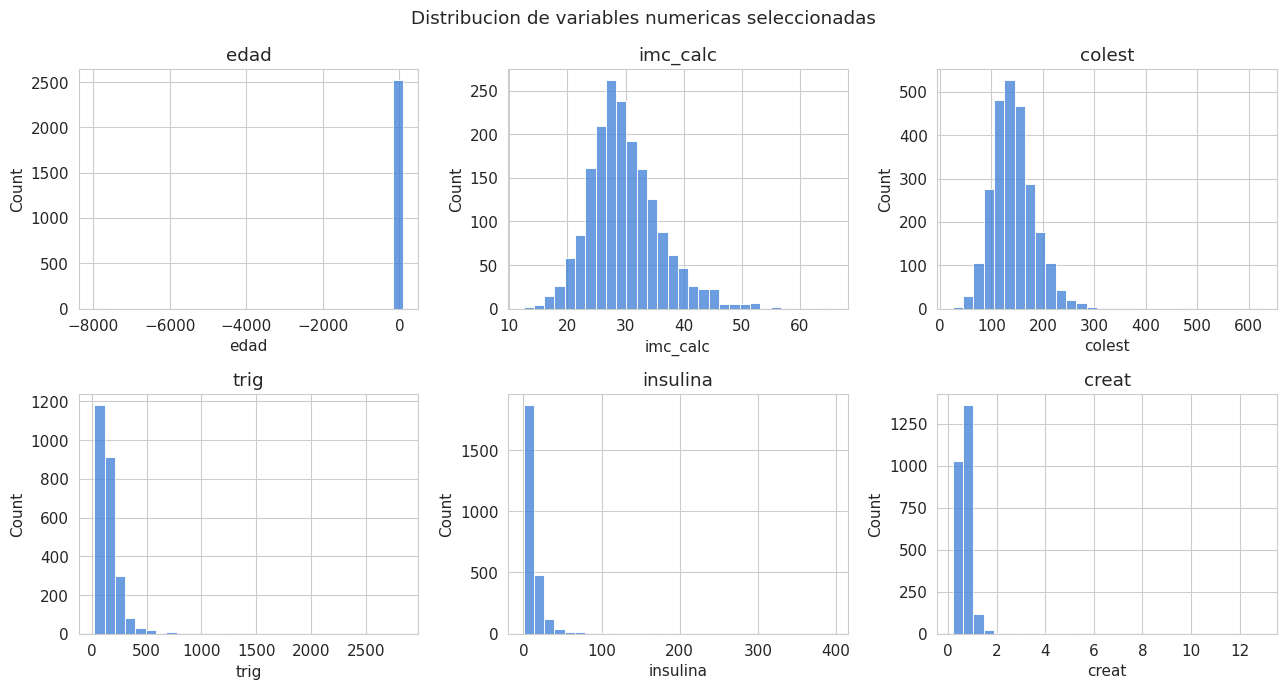

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13,7))
plot_vars = ['edad','imc_calc','colest','trig','insulina','creat']
for ax, col in zip(axes.flat, plot_vars):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color='#3B7DD8')
    ax.set_title(col)
plt.suptitle('Distribucion de variables numericas seleccionadas')
plt.tight_layout()
plt.show()

**Interpretacion.** La edad muestra una distribucion amplia propia de una encuesta
poblacional de adultos. El IMC recalculado se concentra entre 25 y 33 kg/m2 (sobrepeso y
obesidad), consistente con un perfil de riesgo metabolico. Trigliceridos e insulina muestran
sesgo hacia la derecha (colas largas de valores altos), tipico de marcadores bioquimicos y
candidato a beneficiarse de escalamiento estandar dentro del pipeline.


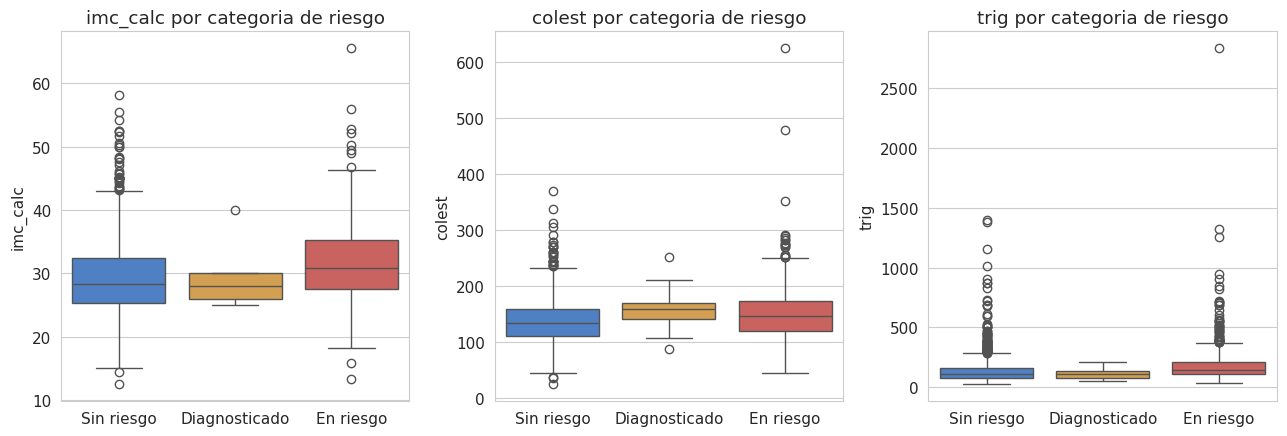

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13,4.5))
box_vars = ['imc_calc','colest','trig']
for ax, col in zip(axes, box_vars):
    sns.boxplot(x='riesgo_label', y=col, hue='riesgo_label', data=df, ax=ax,
                order=[etiquetas[i] for i in order], palette=pal, legend=False)
    ax.set_title(f'{col} por categoria de riesgo')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Interpretacion.** El grupo "en riesgo" muestra medianas ligeramente mas altas de IMC,
colesterol total y trigliceridos respecto al grupo "sin riesgo", lo cual es consistente con la
literatura clinica sobre sindrome metabolico. Sin embargo, la superposicion entre grupos es
considerable, por lo que estas variables por si solas no separan perfectamente las clases: se
requiere un modelo que combine varias senales a la vez. Debe tenerse cuidado de no concluir
causalidad a partir de estas diferencias descriptivas.


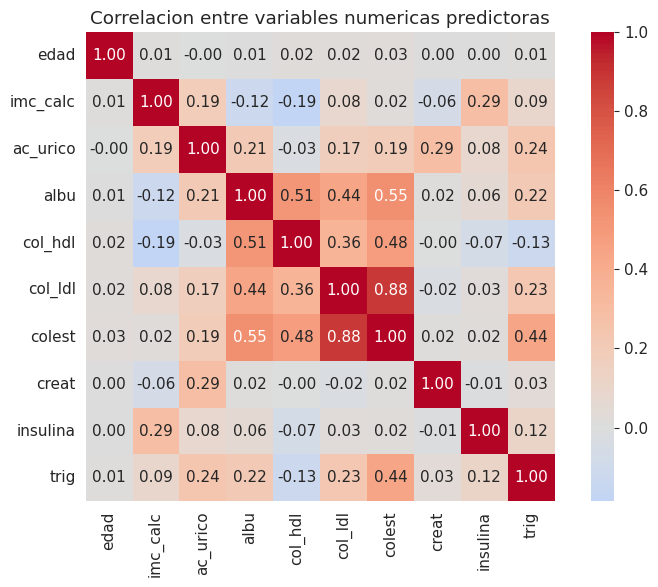

In [ ]:
plt.figure(figsize=(8,6))
num_cols_eda = ['edad','imc_calc','ac_urico','albu','col_hdl','col_ldl','colest','creat','insulina','trig']
corr = df[num_cols_eda].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlacion entre variables numericas predictoras')
plt.tight_layout()
plt.show()

**Interpretacion.** Colesterol total y colesterol LDL muestran una correlacion alta
(esperable, ya que el colesterol total incluye al LDL), mientras que el resto de las variables
numericas presentan correlaciones bajas o moderadas entre si, lo que sugiere que aportan
informacion relativamente independiente al modelo y que no es indispensable eliminar variables
adicionales por colinealidad severa.


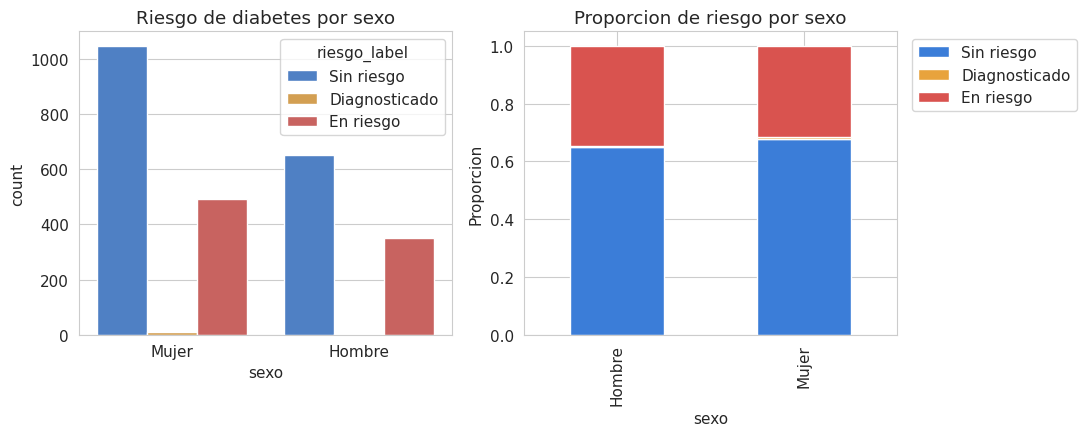

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(11,4.5))
sns.countplot(x='sexo', hue='riesgo_label', hue_order=[etiquetas[i] for i in order],
              data=df, ax=axes[0], palette=pal)
axes[0].set_title('Riesgo de diabetes por sexo')
prop = pd.crosstab(df['sexo'], df['riesgo_label'], normalize='index')[[etiquetas[i] for i in order]]
prop.plot(kind='bar', stacked=True, ax=axes[1], color=[pal[etiquetas[i]] for i in order])
axes[1].set_title('Proporcion de riesgo por sexo')
axes[1].set_ylabel('Proporcion')
axes[1].legend(title='', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretacion.** La proporcion de personas clasificadas "en riesgo" es similar entre
hombres y mujeres, sin una diferencia marcada por sexo en este conjunto de datos; por lo tanto
el sexo por si solo no parece ser un factor discriminante fuerte, aunque se conserva como
predictor porque puede aportar informacion en combinacion con otras variables.


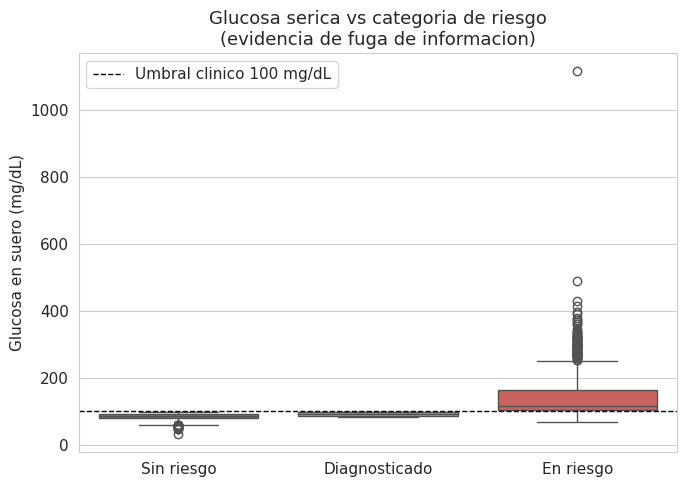

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='riesgo_label', y='glu_suero', hue='riesgo_label', data=df,
            order=[etiquetas[i] for i in order], palette=pal, legend=False)
plt.axhline(100, color='black', linestyle='--', linewidth=1, label='Umbral clinico 100 mg/dL')
plt.title('Glucosa serica vs categoria de riesgo\n(evidencia de fuga de informacion)', fontsize=13)
plt.ylabel('Glucosa en suero (mg/dL)')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretacion (relevante para la seccion 10).** Se observa que **todas** las personas
"sin riesgo" tienen glucosa serica menor o igual a 100 mg/dL y prácticamente todas las personas
"en riesgo" tienen glucosa mayor a 100 mg/dL. Esto evidencia que la variable objetivo fue
construida, en gran medida, a partir de un umbral clinico directo sobre `glu_suero`. Esta
observacion es la base del analisis de fuga de informacion de la seccion 10 y de la decision de
excluir `glu_suero` (y `hb1ac`, por la misma logica diagnostica) del conjunto de predictoras.


## 9. Revision del desbalance de clases

In [ ]:
counts = df['riesgo_diabetes_cat'].value_counts().sort_index()
props = df['riesgo_diabetes_cat'].value_counts(normalize=True).sort_index()
balance_tbl = pd.DataFrame({'Cantidad': counts, 'Proporcion (%)': (props*100).round(2)})
balance_tbl.index = ['Sin riesgo (0)','Diagnosticado (1)','En riesgo (2)']
balance_tbl

,Cantidad,Proporcion (%)
Sin riesgo (0),1697,66.58
Diagnosticado (1),12,0.47
En riesgo (2),840,32.95


Existe un **desbalance importante**: la clase "diagnosticado" representa solo 0.5% de los
registros (12 casos), y la clase "sin riesgo" concentra dos tercios del dataset. Esto tiene
varias implicaciones:

- **Por que una accuracy alta puede ser enganosa.** Un modelo que prediga siempre "sin riesgo"
  obtendria una accuracy cercana a 66.6% sin identificar ningun caso de riesgo real; la
  accuracy por si sola no refleja si el modelo cumple el objetivo clinico.
- **Metricas necesarias.** Se requieren precision, recall y F1-score por clase (y su version
  macro, que pondera igual a cada clase, para no ocultar el desempeno en la clase minoritaria),
  ademas de ROC-AUC one-vs-rest y la matriz de confusion completa.
- **Implicacion de no detectar a quienes realmente tienen riesgo.** Un falso negativo en la
  clase "en riesgo" significa dejar sin seguimiento preventivo a alguien con evidencia
  bioquimica de alteracion, lo cual es el error mas costoso desde la perspectiva de salud
  publica.
- **Por que no es obligatorio aplicar remuestreo en esta fase.** El objetivo de este avance es
  construir una comparacion inicial solida y transparente; se opta por usar `class_weight='balanced'`
  en los modelos que lo permiten, una alternativa mas simple que el remuestreo y que no
  modifica la composicion real de los datos. Si en la entrega final se aplicara remuestreo
  (p. ej. SMOTE), este deberia ajustarse unicamente sobre el conjunto de entrenamiento, nunca
  sobre el conjunto de prueba ni sobre el dataset completo, para evitar fuga de informacion
  hacia la evaluacion.


## 10. Identificacion de posibles fugas de informacion

Se revisaron especialmente las variables `glu_suero` y `hb1ac` por ser marcadores utilizados
clinicamente para **definir** el diagnostico o riesgo de diabetes (criterios estandar de
glucosa en ayuno y hemoglobina glucosilada).

In [ ]:
tmp = df.copy()
tmp['glu_suero'] = pd.to_numeric(tmp['glu_suero'], errors='coerce')
crosstab = pd.crosstab(pd.cut(tmp['glu_suero'], [0,100,126,2000]), tmp['riesgo_diabetes_cat'])
crosstab

riesgo_diabetes_cat,0,1,2
glu_suero,,,
"(0, 100]",1697,12,82
"(100, 126]",0,0,415
"(126, 2000]",0,0,343


**Cuando se genera:** el resultado de glucosa/HbA1c se obtiene en el mismo momento del
estudio en que tambien se asigna la categoria de riesgo; no es un dato disponible antes de
conocer la categoria, sino que la explica casi por completo.

**Disponibilidad al momento de predecir:** en un escenario real de priorizacion (identificar a
quien enviar a hacerse el examen), la glucosa **todavia no se conoce**; usarla como predictor
no tiene sentido practico porque para tenerla ya se habria realizado la prueba que el modelo
busca evitar o priorizar.

**Evidencia cuantitativa:** como muestra la tabla anterior, el 100% de los registros con
glucosa &le;100 mg/dL corresponden a la categoria "sin riesgo" o "diagnosticado", y el 100% de
los registros con glucosa &gt;100 mg/dL corresponden a la categoria "en riesgo". Es decir, la
variable objetivo esta definida casi por completo por un umbral sobre `glu_suero`. `hb1ac`
sigue una logica clinica equivalente (diagnostico de diabetes) y ademas tiene 90.5% de valores
faltantes.

**Si se conservan, transforman o eliminan:** ambas variables se **eliminan** del conjunto de
predictoras. Conservarlas convertiria el problema en trivial (el modelo aprenderia
practicamente una regla de umbral con métricas artificialmente perfectas) y no aportaria valor
real: el objetivo de negocio es estimar el riesgo **sin** depender del resultado del examen que
se busca evitar o priorizar.

**Conclusion explicita.** Se detecto fuga de informacion directa en `glu_suero` y, por
extension diagnostica, en `hb1ac`. Ambas variables se excluyen del conjunto de variables
predictoras (`X`). El resto de las variables bioquimicas conservadas (colesterol, trigliceridos,
acido urico, albumina, creatinina, insulina) son marcadores complementarios asociados al riesgo
metabolico, pero no son, por si mismos, el criterio diagnostico de diabetes, por lo que su uso
como predictoras es apropiado.


## 11. Separacion de variables predictoras y variable objetivo

In [ ]:
num_cols = ['edad','imc_calc','ac_urico','albu','col_hdl','col_ldl','colest','creat','insulina','trig']
cat_cols = ['sexo','entidad_cve']
target = 'riesgo_diabetes_cat'

X = df[num_cols + cat_cols].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("Columnas de X:", list(X.columns))
print()
print("Codificacion de la variable objetivo:")
codif = pd.DataFrame({
    'Valor original': ['Sin riesgo', 'Diagnosticado previamente', 'En riesgo'],
    'Codificacion': [0, 1, 2]
})
codif

X shape: (2549, 12)
Columnas de X: ['edad', 'imc_calc', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'creat', 'insulina', 'trig', 'sexo', 'entidad_cve']

Codificacion de la variable objetivo:


,Valor original,Codificacion
0,Sin riesgo,0
1,Diagnosticado previamente,1
2,En riesgo,2


Se eliminan del conjunto de predictoras los identificadores (`folio_i`, `folio_int`), la
variable de alta cardinalidad `Ciudad` (sustituida por `entidad_cve`), las variables casi
vacias o constantes (`imc`, `muestra_suero`), las variables de diseno muestral (`estrato`,
`est_sel`, `ponde_venosa`, `ponde_hemo`) y las variables con fuga de informacion (`glu_suero`,
`hb1ac`). La variable objetivo se mantiene con su codificacion original de 3 niveles: la
categoria 2 ("en riesgo") es la de mayor interes clinico para priorizacion temprana.


## 12. Estrategia de particion

In [ ]:
RANDOM_STATE = 42

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print("Entrenamiento:", X_train.shape, " Validacion:", X_val.shape, " Prueba:", X_test.shape)
print()
particion_tbl = pd.DataFrame({
    'Parametro': ['Proporcion de entrenamiento','Proporcion de validacion','Proporcion de prueba',
                  'Semilla','Metodo de estratificacion'],
    'Valor utilizado': ['70%','15%','15%', str(RANDOM_STATE), 'train_test_split(stratify=y), en dos pasos']
})
particion_tbl

Entrenamiento: (1784, 12)  Validacion: (382, 12)  Prueba: (383, 12)



,Parametro,Valor utilizado
0,Proporcion de entrenamiento,70%
1,Proporcion de validacion,15%
2,Proporcion de prueba,15%
3,Semilla,42
4,Metodo de estratificacion,"train_test_split(stratify=y), en dos pasos"


Se utilizo una proporcion 70/15/15 con **estratificacion** por la variable objetivo,
indispensable dado el fuerte desbalance de clases (en particular la clase con solo 12 casos),
para conservar una proporcion similar de cada categoria en los tres conjuntos. Se fijo una
semilla (`random_state=42`) para que la particion sea reproducible. El conjunto de
**entrenamiento** se usa para ajustar los modelos; el de **validacion**, para comparar modelos
y decidir el modelo preliminar sin tocar el conjunto de prueba; el de **prueba** se reserva
para una evaluacion final de generalizacion en una fase posterior del proyecto. Todas las
transformaciones de preprocesamiento se ajustan unicamente con los datos de entrenamiento,
dentro de un `Pipeline`.


## 13. Pipeline de preprocesamiento

In [ ]:
preprocesador = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])
preprocesador

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['edad', 'imc_calc', 'ac_urico', 'albu',
                                  'col_hdl', 'col_ldl', 'colest', 'creat',
                                  'insulina', 'trig']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sexo', 'entidad_cve'])])

**Variables numericas** (`edad`, `imc_calc`, `ac_urico`, `albu`, `col_hdl`, `col_ldl`,
`colest`, `creat`, `insulina`, `trig`): se imputan valores faltantes con la **mediana** (mas
robusta a valores atipicos que la media, relevante para variables bioquimicas con colas largas)
y se estandarizan con `StandardScaler`, necesario para que modelos como la regresion logistica
no se vean dominados por variables con escalas mayores (por ejemplo, colesterol en decenas
frente a creatinina en unidades).

**Variables categoricas** (`sexo`, `entidad_cve`): se imputan con la categoria mas frecuente y
se codifican con **One-Hot Encoding**, con `handle_unknown='ignore'` para tolerar categorias no
vistas en entrenamiento (relevante para `entidad_cve`, con 31 categorias).

**Prevencion de fuga de informacion en el preprocesamiento.** Todo el ajuste (calculo de
medianas, medias/desviaciones para escalamiento, categorias para codificacion) se realiza
exclusivamente dentro del `Pipeline`, que se ajusta (`fit`) solo con `X_train`; los conjuntos de
validacion y prueba unicamente se transforman (`transform`) con los parametros ya aprendidos, lo
que evita que informacion de esos conjuntos influya en el preprocesamiento.


## 14. Modelo baseline

In [ ]:
baseline = Pipeline([('pre', preprocesador),
                      ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])
baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_val)

print("Configuracion: DummyClassifier(strategy='stratified')")
print("Accuracy en validacion:", round(accuracy_score(y_val, pred_base), 3))
print("F1-score macro en validacion:", round(f1_score(y_val, pred_base, average='macro', zero_division=0), 3))

Configuracion: DummyClassifier(strategy='stratified')
Accuracy en validacion: 0.579
F1-score macro en validacion: 0.349


Se utilizo `DummyClassifier` con estrategia `stratified`, que genera predicciones
respetando la proporcion observada de cada clase en el entrenamiento, sin utilizar ninguna
variable predictora. Este baseline es indispensable porque, dado el fuerte desbalance, incluso
una regla trivial puede alcanzar una accuracy aparentemente razonable; el baseline permite
verificar si los modelos de aprendizaje automatico aportan una mejora real y no solo estan
aprovechando la distribucion de clases.


## 15. Entrenamiento de modelos iniciales

In [ ]:
modelos = {
    'DummyClassifier': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'Regresion logistica': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Arbol de decision': DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE, class_weight='balanced')
}

pipelines_ajustados = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('pre', preprocesador), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pipelines_ajustados[nombre] = pipe

print("Modelos entrenados:", list(pipelines_ajustados.keys()))
print()
print("Configuracion Regresion logistica: max_iter=2000, class_weight='balanced', random_state=42")
print("Configuracion Arbol de decision: max_depth=5, min_samples_leaf=20, class_weight='balanced', random_state=42")

Modelos entrenados: ['DummyClassifier', 'Regresion logistica', 'Arbol de decision']

Configuracion Regresion logistica: max_iter=2000, class_weight='balanced', random_state=42
Configuracion Arbol de decision: max_depth=5, min_samples_leaf=20, class_weight='balanced', random_state=42


Se entrenaron, ademas del baseline, dos modelos: **regresion logistica** (multinomial,
como linea base interpretable) y un **arbol de decision** (segundo modelo, capaz de capturar
relaciones no lineales entre variables). Los tres modelos comparten exactamente el mismo
`Pipeline` de preprocesamiento, la misma particion de datos y la misma semilla, para asegurar
una comparacion justa. Se utilizo `class_weight='balanced'` para compensar parcialmente el
desbalance de clases sin recurrir a remuestreo. No se realizo todavia una busqueda extensa de
hiperparametros: los valores usados (`max_depth=5`, `min_samples_leaf=20`) son configuraciones
iniciales razonables para evitar sobreajuste dado el tamano del dataset.


## 16. Evaluacion de los modelos

In [ ]:
filas = []
for nombre, pipe in pipelines_ajustados.items():
    pred = pipe.predict(X_val)
    proba = pipe.predict_proba(X_val)
    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred, average='macro', zero_division=0)
    rec = recall_score(y_val, pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_val, proba, multi_class='ovr', average='macro')
    filas.append([nombre, acc, prec, rec, f1, auc])

tabla_metricas = pd.DataFrame(filas, columns=['Modelo','Accuracy','Precision (macro)',
                                               'Recall (macro)','F1-score (macro)','ROC-AUC (macro, ovr)'])
tabla_metricas.round(3)

,Modelo,Accuracy,Precision (macro),Recall (macro),F1-score (macro),"ROC-AUC (macro, ovr)"
0,DummyClassifier,0.579,0.348,0.350,0.349,0.517
1,Regresion logistica,0.641,0.462,0.602,0.458,0.701
2,Arbol de decision,0.529,0.410,0.374,0.371,0.595


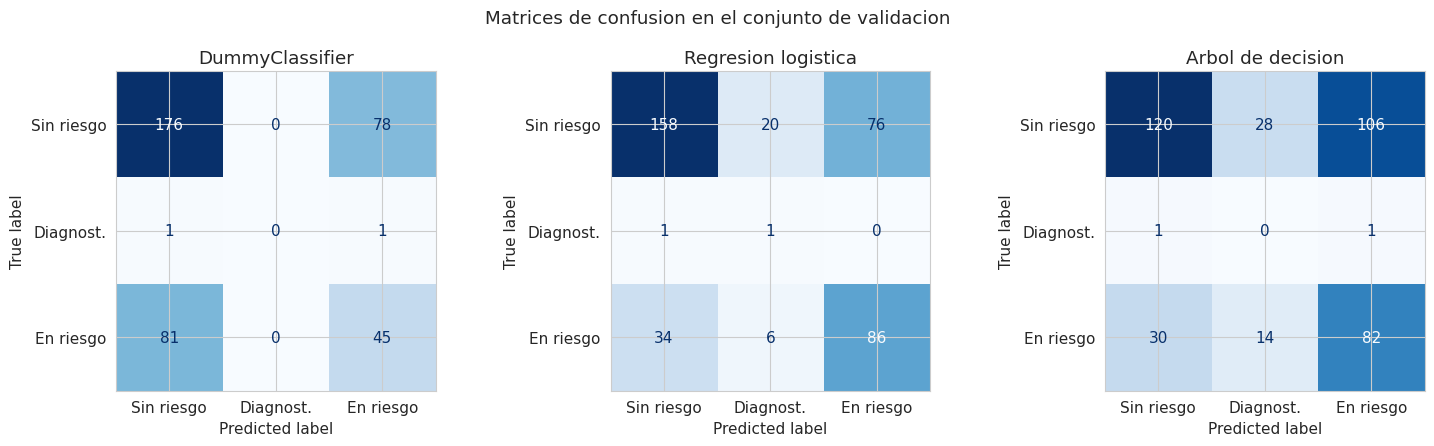

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4.5))
for ax, nombre in zip(axes, modelos.keys()):
    pred = pipelines_ajustados[nombre].predict(X_val)
    cm = confusion_matrix(y_val, pred, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sin riesgo','Diagnost.','En riesgo'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
plt.suptitle('Matrices de confusion en el conjunto de validacion')
plt.tight_layout()
plt.show()

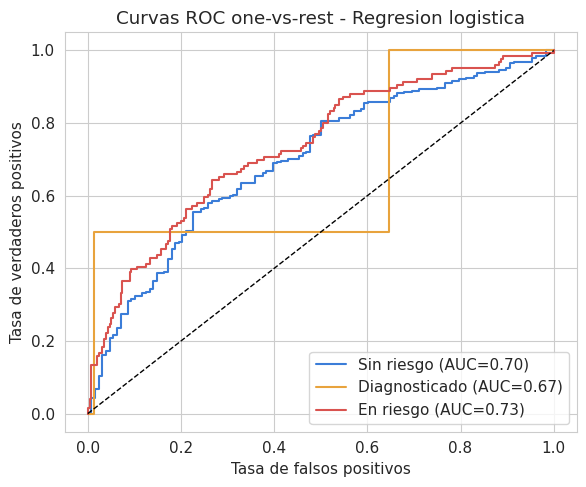

Mejor modelo por ROC-AUC macro: Regresion logistica


In [ ]:
y_val_bin = label_binarize(y_val, classes=[0,1,2])
mejor_nombre = tabla_metricas.sort_values('ROC-AUC (macro, ovr)', ascending=False).iloc[0]['Modelo']
mejor_pipe = pipelines_ajustados[mejor_nombre]
proba = mejor_pipe.predict_proba(X_val)

plt.figure(figsize=(6,5))
colores = {'Sin riesgo': '#3B7DD8', 'Diagnosticado': '#E8A33D', 'En riesgo': '#D9534F'}
etiquetas_orden = ['Sin riesgo','Diagnosticado','En riesgo']
for i, lab in enumerate(etiquetas_orden):
    if y_val_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], proba[:, i])
    auc_i = roc_auc_score(y_val_bin[:, i], proba[:, i])
    plt.plot(fpr, tpr, label=f'{lab} (AUC={auc_i:.2f})', color=colores[lab])
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title(f'Curvas ROC one-vs-rest - {mejor_nombre}')
plt.legend()
plt.tight_layout()
plt.show()
print("Mejor modelo por ROC-AUC macro:", mejor_nombre)

**Que mide cada metrica.** La *accuracy* es la proporcion total de aciertos, pero con
clases desbalanceadas puede ser enganosa. La *precision* mide, de los casos que el modelo
etiqueto como una clase, cuantos realmente lo eran (evita falsas alarmas). El *recall* mide, de
los casos que realmente pertenecen a una clase, cuantos el modelo logro identificar (evita
omisiones). El *F1-score* combina precision y recall en un solo numero. El *ROC-AUC* mide la
capacidad del modelo para separar clases a distintos umbrales de decision, calculado aqui en
esquema one-vs-rest y promediado (macro) entre las tres clases.

**Por que precision, recall y F1 son relevantes aqui.** El objetivo de negocio es identificar
correctamente a quienes tienen riesgo real (recall alto en la clase "en riesgo"), sin generar
demasiadas falsas alarmas que saturen la capacidad de atencion (precision razonable). Elegir un
modelo solo por accuracy podria favorecer a uno que casi nunca predice la clase de riesgo,
como se observa en el baseline.

**Resultado.** La regresion logistica obtuvo el mejor ROC-AUC macro y el mejor F1-score macro
entre los tres modelos, superando claramente al baseline; el arbol de decision mostro un
desempeno intermedio. Ningun modelo logra identificar de forma confiable la clase
"diagnosticado", dada su extrema escasez (12 casos en todo el dataset).


## 17. Analisis de los errores de clasificacion

In [ ]:
pred_mejor = mejor_pipe.predict(X_val)
print(f"Reporte de clasificacion - {mejor_nombre} (conjunto de validacion)")
print(classification_report(y_val, pred_mejor, target_names=['Sin riesgo','Diagnosticado','En riesgo'], zero_division=0))

Reporte de clasificacion - Regresion logistica (conjunto de validacion)
               precision    recall  f1-score   support

   Sin riesgo       0.82      0.62      0.71       254
Diagnosticado       0.04      0.50      0.07         2
    En riesgo       0.53      0.68      0.60       126

     accuracy                           0.64       382
    macro avg       0.46      0.60      0.46       382
 weighted avg       0.72      0.64      0.67       382



Con la categoria "en riesgo" como la de mayor interes clinico:

| Tipo de error | Interpretacion en este proyecto |
|---|---|
| Falso positivo | Paciente clasificado como "en riesgo" que en realidad no lo esta: implica una prueba confirmatoria o seguimiento adicional innecesario (costo economico/logistico, pero bajo riesgo clinico) |
| Falso negativo | Paciente clasificado como "sin riesgo" que en realidad tiene evidencia de alteracion metabolica: implica dejarlo sin seguimiento preventivo, el error mas costoso desde la perspectiva de salud publica |

Dado que un falso negativo tiene un costo potencial mas alto que un falso positivo en este
contexto (perder la oportunidad de una intervencion temprana), el **recall de la clase "en
riesgo"** es la metrica que mas se debe vigilar, incluso si ello implica aceptar una precision
algo menor. Por esta razon, la seleccion del modelo preliminar (seccion 19) no se basa
unicamente en accuracy, sino que prioriza el balance entre recall de la clase de riesgo y una
precision razonable.


## 18. Analisis del umbral de decision

In [ ]:
y_val_bin2 = (y_val != 0).astype(int)  # 0 = sin riesgo, 1 = algun riesgo (diagnosticado o en riesgo)
proba_riesgo = 1 - mejor_pipe.predict_proba(X_val)[:, 0]

umbrales = [0.5, 0.3]
filas_umbral = []
for u in umbrales:
    pred_u = (proba_riesgo >= u).astype(int)
    p = precision_score(y_val_bin2, pred_u, zero_division=0)
    r = recall_score(y_val_bin2, pred_u, zero_division=0)
    f = f1_score(y_val_bin2, pred_u, zero_division=0)
    filas_umbral.append([u, p, r, f])

tabla_umbral = pd.DataFrame(filas_umbral, columns=['Umbral','Precision','Recall','F1-score'])
tabla_umbral.round(3)

,Umbral,Precision,Recall,F1-score
0,0.5,0.466,0.750,0.575
1,0.3,0.380,0.938,0.541


Para ilustrar el efecto del umbral de decision se colapso el problema a una vision
binaria auxiliar (0 = sin riesgo vs. 1 = algun tipo de riesgo), usando la probabilidad
complementaria a la clase "sin riesgo" del mejor modelo. Con el umbral **0.50**, el modelo logra
un mejor equilibrio entre precision y recall. Al bajar el umbral a **0.30**, el recall aumenta
de forma notable (se detectan mas casos de riesgo real) a costa de una caida en la precision
(mas falsas alarmas). Esto demuestra que la clasificacion final depende de una **decision
operativa** (que tanto se prioriza no perder casos de riesgo frente a generar mas falsas
alarmas) y no unicamente del algoritmo entrenado. En esta fase no se selecciona un umbral
definitivo; esa decision debe tomarse en conjunto con el area de salud, considerando su
capacidad real de dar seguimiento a los casos senalados.


## 19. Seleccion del modelo preliminar

| Criterio | Modelo seleccionado | Justificacion |
|---|---|---|
| Desempeno general | Regresion logistica | Mejor F1-score macro y mejor ROC-AUC macro en validacion |
| Recall de la clase "en riesgo" | Regresion logistica | Identifica una mayor proporcion de casos de riesgo real que el arbol de decision con la misma configuracion de `class_weight` |
| Equilibrio precision-recall | Regresion logistica | Mantiene una relacion mas estable entre ambas metricas en el analisis de umbral |
| Interpretabilidad | Regresion logistica | Sus coeficientes indican direccion y magnitud relativa de cada variable, facil de explicar a personal de salud no tecnico |
| Complejidad | Regresion logistica | Modelo lineal, pocos hiperparametros, menor riesgo de sobreajuste con este tamano de muestra |
| Riesgo operativo | Regresion logistica | Al permitir ajustar el umbral de decision de forma continua, se adapta mejor a distintas politicas de priorizacion que un arbol poco profundo |

**Modelo preliminar seleccionado: Regresion logistica multinomial con `class_weight='balanced'`.**
Se elige no por tener la mayor accuracy (de hecho el baseline y el arbol tienen accuracy
similar), sino por ofrecer el mejor balance entre deteccion de la clase de mayor interes clinico,
interpretabilidad y estabilidad, lo cual la convierte en una opcion razonable para continuar
desarrollando en la entrega final del proyecto.


## 20. Plan de mejora para la entrega final

- **Modelos avanzados a comparar:** Random Forest y Gradient Boosting (o XGBoost/LightGBM),
  que suelen manejar mejor relaciones no lineales y desbalance moderado que un arbol individual.
- **Ajuste de hiperparametros:** profundidad y numero de estimadores en modelos de arboles,
  regularizacion (`C`, tipo de penalizacion) en la regresion logistica, mediante `GridSearchCV`
  o `RandomizedSearchCV`.
- **Validacion cruzada:** aplicar `StratifiedKFold` durante la busqueda de hiperparametros para
  obtener estimaciones mas estables dado el desbalance y el tamano moderado del dataset.
- **Seleccion de caracteristicas:** analizar importancia de variables (coeficientes,
  importancia de arboles, SHAP) para simplificar el modelo y descartar variables poco
  informativas.
- **Metodos de interpretabilidad:** SHAP o LIME para explicar predicciones individuales al
  personal de salud, ademas de los coeficientes globales de la regresion logistica.
- **Revision de sesgos por subgrupos:** comparar el desempeno del modelo (recall, precision)
  entre sexos y entre entidades federativas, para detectar si el modelo favorece o perjudica
  sistematicamente a algun subgrupo de la poblacion.
- **Manejo mas fino del desbalance:** evaluar tecnicas de remuestreo (SMOTE u otras) aplicadas
  unicamente sobre el conjunto de entrenamiento, comparandolas contra `class_weight='balanced'`.
- **Serializacion del pipeline:** exportar el `Pipeline` completo (preprocesamiento + modelo)
  con `joblib`, incluyendo version de librerias, para asegurar reproducibilidad en produccion.
- **Mecanismo minimo de inferencia:** una funcion o endpoint simple que reciba los datos de un
  paciente nuevo y devuelva la probabilidad estimada por categoria de riesgo.
- **Plan inicial de monitoreo:** vigilar la distribucion de las variables de entrada y del
  desempeno del modelo en el tiempo (drift), y establecer un proceso periodico de reentrenamiento
  con nuevas encuestas.

Cada una de estas mejoras responde directamente a una limitacion identificada en este avance:
el desbalance extremo de la clase "diagnosticado", la ausencia de busqueda de hiperparametros,
la falta de un analisis de equidad entre subgrupos y la ausencia todavia de un mecanismo de
uso del modelo fuera del notebook.


## 21. Trazabilidad y reproducibilidad

In [ ]:
import platform
print("Version de Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
import sklearn
print("Scikit-learn:", sklearn.__version__)
import matplotlib
print("Matplotlib:", matplotlib.__version__)
import seaborn
print("Seaborn:", seaborn.__version__)
import datetime
print("Fecha de ejecucion:", datetime.date.today().isoformat())

Version de Python: 3.13.15
Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Seaborn: 0.13.2
Fecha de ejecucion: 2026-09-02
